## Импорты и данные

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

In [22]:
news_old = pd.read_parquet('news_descriptions/news_collection_old.parquet')
news_old['date'] = pd.to_datetime(news_old['date']).dt.normalize()

gpt4o = pd.read_json('news_descriptions/news_descriptions_GPT4o.json').transpose()

valid_tickers = set(pd.read_json('tickers_description.json', orient='index').index)

def clean_tickers(raw):
    if not isinstance(raw, list): return []
    return [t.strip('#$') for t in raw if t.strip('#$') in valid_tickers]

sentiment_news = pd.concat([news_old.reset_index(drop=True), gpt4o.reset_index(drop=True)], axis=1)[:15000]
sentiment_news = sentiment_news[sentiment_news['body'].astype(str) != '""']
sentiment_news['tickers']         = sentiment_news['tickers'].apply(clean_tickers)
sentiment_news['sentiment_score'] = pd.to_numeric(sentiment_news['sentiment_score'], errors='coerce')

In [23]:
moex = pd.read_csv('MOEX.csv', encoding='cp1251', sep=';', engine='python', on_bad_lines='warn')
moex['date']   = pd.to_datetime(moex['TRADEDATE'], dayfirst=True)
moex['close']  = moex['CLOSE'].astype(str).str.replace(',', '.').astype(float)
moex['return'] = moex['close'].pct_change()
moex = moex[['date', 'close', 'return']].dropna().reset_index(drop=True)

daily_sentiment = (
    sentiment_news
    .groupby('date')['sentiment_score']
    .mean()
    .reset_index()
    .rename(columns={'sentiment_score': 'sentiment_index'})
)

final_df = moex.merge(daily_sentiment, on='date', how='inner').reset_index(drop=True)
print('final_df:', final_df.shape)
final_df.head()

final_df: (593, 4)


,date,close,return,sentiment_index
0,2022-06-14,2289.75,0.001851,0.300000
1,2022-06-15,2318.96,0.012757,-0.331250
2,2022-06-16,2369.75,0.021902,0.572727
3,2022-06-17,2353.98,-0.006655,0.180000
4,2022-06-20,2404.40,0.021419,0.078947


## Инжиниринг признаков

In [24]:
df = final_df.copy()

df['sent_lag1']   = df['sentiment_index'].shift(1)
df['sent_lag2']   = df['sentiment_index'].shift(2)
df['sent_lag3']   = df['sentiment_index'].shift(3)
df['sent_roll3']  = df['sentiment_index'].rolling(3).mean()
df['sent_roll5']  = df['sentiment_index'].rolling(5).mean()
df['return_lag1'] = df['return'].shift(1)
df['return_lag2'] = df['return'].shift(2)

df = df.dropna().reset_index(drop=True)
print('После удаления NaN:', df.shape)
df.head()

После удаления NaN: (589, 11)


,date,close,return,sentiment_index,sent_lag1,sent_lag2,sent_lag3,sent_roll3,sent_roll5,return_lag1,return_lag2
0,2022-06-20,2404.40,0.021419,0.078947,0.180000,0.572727,-0.331250,0.277225,0.160085,-0.006655,0.021902
1,2022-06-21,2358.81,-0.018961,0.018182,0.078947,0.180000,0.572727,0.092376,0.103721,0.021419,-0.006655
2,2022-06-22,2373.52,0.006236,-0.430000,0.018182,0.078947,0.180000,-0.110957,0.083971,-0.018961,0.021419
3,2022-06-23,2404.54,0.013069,-0.166667,-0.430000,0.018182,0.078947,-0.192828,-0.063907,0.006236,-0.018961
4,2022-06-24,2391.51,-0.005419,-0.345455,-0.166667,-0.430000,0.018182,-0.314040,-0.168998,0.013069,0.006236


## Целевая переменная

`target = 1` — рынок вырастет завтра, `target = 0` — упадёт.

In [25]:
df['target'] = (df['return'].shift(-1) > 0).astype(int)
df = df.dropna().reset_index(drop=True)

print('Распределение классов:')
print(df['target'].value_counts())
print(f'Доля роста: {df["target"].mean():.2%}')

Распределение классов:
target
1    332
0    257
Name: count, dtype: int64
Доля роста: 56.37%


## Разбивка на train / test

Хронологическая — без перемешивания, чтобы не было утечки из будущего.

In [26]:
FEATURES = ['sentiment_index', 'sent_lag1', 'sent_lag2', 'sent_lag3',
            'sent_roll3', 'sent_roll5', 'return_lag1', 'return_lag2']

X = df[FEATURES]
y = df['target']

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print(f'Train период: {df["date"].iloc[0].date()} → {df["date"].iloc[split-1].date()}')
print(f'Test  период: {df["date"].iloc[split].date()} → {df["date"].iloc[-1].date()}')

Train: 471  |  Test: 118
Train период: 2022-06-20 → 2024-04-23
Test  период: 2024-04-24 → 2024-12-09


## Масштабирование признаков

In [27]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## Обучение модели — Random Forest

In [28]:
model = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42, n_jobs=-1)
model.fit(X_train_sc, y_train)
print('Модель обучена')

Модель обучена


## Оценка качества

In [29]:
y_pred      = model.predict(X_test_sc)
y_pred_prob = model.predict_proba(X_test_sc)[:, 1]

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_pred_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Падение', 'Рост']))

Accuracy : 0.5085
ROC-AUC  : 0.5651

              precision    recall  f1-score   support

     Падение       0.67      0.03      0.06        59
        Рост       0.50      0.98      0.67        59

    accuracy                           0.51       118
   macro avg       0.59      0.51      0.37       118
weighted avg       0.59      0.51      0.37       118



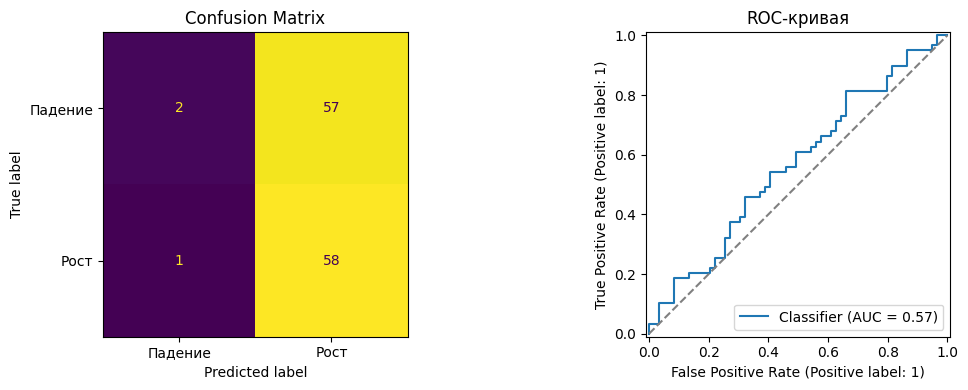

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['Падение', 'Рост']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1])
axes[1].set_title('ROC-кривая')
axes[1].plot([0, 1], [0, 1], '--', color='grey')

plt.tight_layout()
plt.show()

## Важность признаков

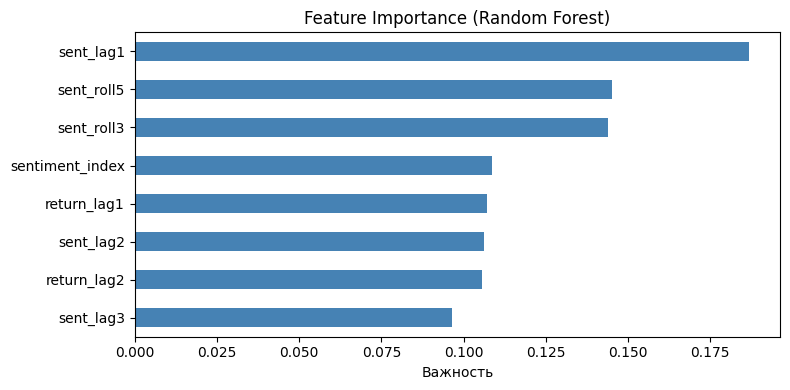

In [31]:
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Важность')
plt.tight_layout()
plt.show()

## Кросс-валидация (TimeSeriesSplit)

Проверяем устойчивость модели на 5 последовательных фолдах.

In [32]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42, n_jobs=-1),
    scaler.fit_transform(X), y,
    cv=tscv, scoring='roc_auc'
)

for i, s in enumerate(cv_scores, 1):
    print(f'Fold {i}: ROC-AUC = {s:.4f}')
print(f'\nСреднее: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Fold 1: ROC-AUC = 0.4692
Fold 2: ROC-AUC = 0.4588
Fold 3: ROC-AUC = 0.4728
Fold 4: ROC-AUC = 0.5412
Fold 5: ROC-AUC = 0.5540

Среднее: 0.4992 ± 0.0400


---
## Улучшенная модель

Три ключевых изменения относительно базовой модели:
1. **Только `finance` новости** — убираем рекламу, опросы, технический анализ
2. **Распределение сентимента** — добавляем std и кол-во новостей за день как признаки
3. **Gradient Boosting** — более мощный алгоритм с подбором гиперпараметров

In [33]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

### Фильтрация и агрегация

In [34]:
finance_news = sentiment_news[sentiment_news['article_type'] == 'finance']
print(f'Finance новостей: {len(finance_news)} из {len(sentiment_news)} ({len(finance_news)/len(sentiment_news):.0%})')

daily_rich = (
    finance_news
    .groupby('date')['sentiment_score']
    .agg(sentiment_index='mean', sent_std='std', news_count='count')
    .reset_index()
    .fillna({'sent_std': 0})
)

df2 = moex.merge(daily_rich, on='date', how='inner').reset_index(drop=True)
print('Дней с finance-новостями:', len(df2))

Finance новостей: 11653 из 14772 (79%)
Дней с finance-новостями: 589


### Расширенный инжиниринг признаков

In [35]:
for i in range(1, 6): df2[f'sent_lag{i}']    = df2['sentiment_index'].shift(i)
for i in range(1, 4): df2[f'return_lag{i}']  = df2['return'].shift(i)
df2['sent_diff']    = df2['sentiment_index'].diff()
df2['sent_roll3']   = df2['sentiment_index'].rolling(3).mean()
df2['sent_roll5']   = df2['sentiment_index'].rolling(5).mean()
df2['sent_vol5']    = df2['sentiment_index'].rolling(5).std()
df2['return_vol5']  = df2['return'].rolling(5).std()
df2['momentum3']    = df2['close'].pct_change(3)
df2['target']       = (df2['return'].shift(-1) > 0).astype(int)
df2 = df2.dropna().reset_index(drop=True)

FEATURES2 = ['sentiment_index', 'sent_std', 'news_count',
             'sent_lag1', 'sent_lag2', 'sent_lag3', 'sent_lag4', 'sent_lag5',
             'sent_diff', 'sent_roll3', 'sent_roll5', 'sent_vol5',
             'return_lag1', 'return_lag2', 'return_lag3', 'return_vol5', 'momentum3']

X2 = df2[FEATURES2]
y2 = df2['target']
split2 = int(len(df2) * 0.8)

X2_train, X2_test = X2.iloc[:split2], X2.iloc[split2:]
y2_train, y2_test = y2.iloc[:split2], y2.iloc[split2:]

scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)
print('Train / Test:', len(X2_train), '/', len(X2_test))

Train / Test: 467 / 117


### Подбор гиперпараметров (GridSearchCV + TimeSeriesSplit)

In [36]:
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [2, 3],
    'learning_rate': [0.03, 0.05, 0.1],
}

gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    n_jobs=-1,
)
gs.fit(X2_train_sc, y2_train)

print('Лучшие параметры:', gs.best_params_)
print(f'CV ROC-AUC (train): {gs.best_score_:.4f}')

Лучшие параметры: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100}
CV ROC-AUC (train): 0.5481


### Оценка улучшенной модели

In [37]:
best_model = gs.best_estimator_
y2_pred     = best_model.predict(X2_test_sc)
y2_prob     = best_model.predict_proba(X2_test_sc)[:, 1]

print(f'Accuracy : {accuracy_score(y2_test, y2_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y2_test, y2_prob):.4f}')
print()
print(classification_report(y2_test, y2_pred, target_names=['Падение', 'Рост']))

Accuracy : 0.5214
ROC-AUC  : 0.5263

              precision    recall  f1-score   support

     Падение       0.75      0.10      0.18        60
        Рост       0.50      0.96      0.66        57

    accuracy                           0.52       117
   macro avg       0.63      0.53      0.42       117
weighted avg       0.63      0.52      0.41       117



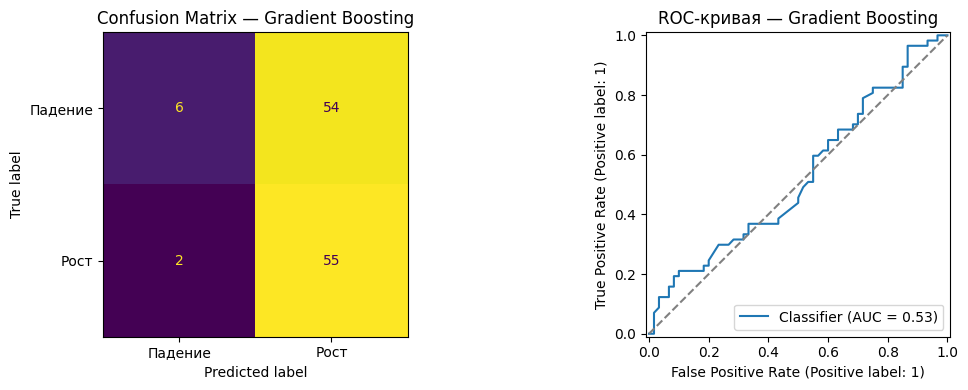

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred),
                       display_labels=['Падение', 'Рост']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Gradient Boosting')

RocCurveDisplay.from_predictions(y2_test, y2_prob, ax=axes[1])
axes[1].plot([0, 1], [0, 1], '--', color='grey')
axes[1].set_title('ROC-кривая — Gradient Boosting')

plt.tight_layout()
plt.show()

### Важность признаков

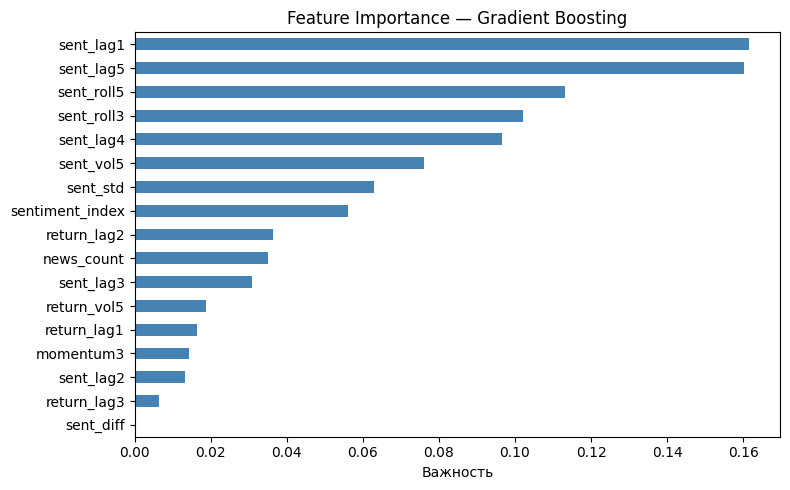

In [39]:
importance2 = pd.Series(best_model.feature_importances_, index=FEATURES2).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importance2.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance — Gradient Boosting')
ax.set_xlabel('Важность')
plt.tight_layout()
plt.show()

### Сравнение базовой и улучшенной модели

                        Модель  ROC-AUC    Std
       Random Forest (базовая)   0.4992 0.0400
Gradient Boosting (улучшенная)   0.5739 0.0475


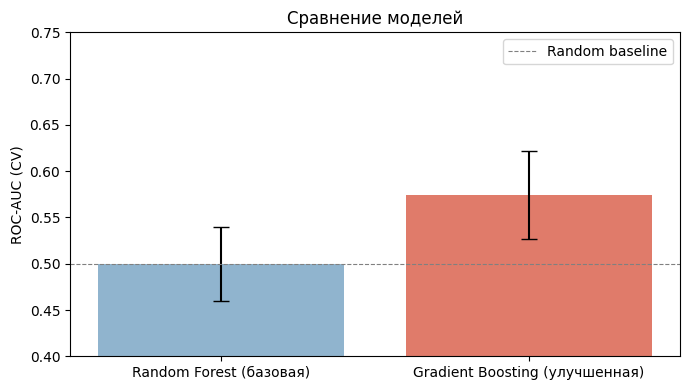

In [40]:
tscv = TimeSeriesSplit(n_splits=5)

cv_base = cross_val_score(
    RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42, n_jobs=-1),
    StandardScaler().fit_transform(df[FEATURES]), df['target'],
    cv=tscv, scoring='roc_auc'
)
cv_improved = cross_val_score(
    GradientBoostingClassifier(**gs.best_params_, random_state=42),
    scaler2.fit_transform(X2), y2,
    cv=tscv, scoring='roc_auc'
)

comparison = pd.DataFrame({
    'Модель':   ['Random Forest (базовая)', 'Gradient Boosting (улучшенная)'],
    'ROC-AUC':  [cv_base.mean(),            cv_improved.mean()],
    'Std':      [cv_base.std(),             cv_improved.std()],
})
comparison['ROC-AUC'] = comparison['ROC-AUC'].round(4)
comparison['Std']     = comparison['Std'].round(4)
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comparison['Модель'], comparison['ROC-AUC'],
       yerr=comparison['Std'], capsize=6, color=['#90b4ce','#e07b6a'])
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Random baseline')
ax.set_ylim(0.4, 0.75)
ax.set_ylabel('ROC-AUC (CV)')
ax.set_title('Сравнение моделей')
ax.legend()
plt.tight_layout()
plt.show()